In [1]:
import sys
sys.path.append("/home/mariacst/exoplanets/debug/multinest/power_law/non_linear/")

import _utils
import imp
imp.reload(_utils)
import numpy as np

from astropy.constants import G, sigma_sb, R_jup, c, M_sun
import astropy.units as u

import matplotlib.pyplot as plt
from _utils import T_DM

from scipy.misc import derivative

In [2]:
path = "/home/mariacst/exoplanets/running/data/"

masses, a, b = np.genfromtxt(path + "derv_ana_wrt_A.dat", unpack=True)           
ages, c = np.genfromtxt(path + "derv_ana_wrt_M.dat", unpack=True)             

from scipy.interpolate import interp1d
from scipy.interpolate import griddata

a_interp = interp1d(masses, a)                                                   
b_interp = interp1d(masses, b)                                                    
c_interp = interp1d(ages, c)
                                  
data = np.genfromtxt(path + "./ATMO_CEQ_vega_MIRI.txt", unpack=True)               
points = np.transpose(data[0:2, :])                                                
values = data[2] 

# Second derivative temperature with respect to mass

\begin{equation}
    \frac{\partial^2T}{\partial M^2}
\end{equation}

<p style="color:red;">
FIXME: some issues with xi and griddata when vectorising. See below   
</p>

**Second derivative TDM wrt mass**

In [5]:
imp.reload(_utils)
from _utils import dderivativeTDM_wrt_M, dderivativeT_wrt_M
from _utils import PL_T_DM

In [6]:
path = "/home/mariacst/exoplanets/running/data/"

masses, a, b = np.genfromtxt(path + "derv_ana_wrt_A.dat", unpack=True)           
ages, c = np.genfromtxt(path + "derv_ana_wrt_M.dat", unpack=True)             

from scipy.interpolate import interp1d
from scipy.interpolate import griddata

a_interp = interp1d(masses, a)                                                   
b_interp = interp1d(masses, b)                                                    
c_interp = interp1d(ages, c)
                                  
data = np.genfromtxt(path + "./ATMO_CEQ_vega_MIRI.txt", unpack=True)               
points = np.transpose(data[0:2, :])                                                
values = data[2] 

In [9]:
r=0.1; A_cte=300.; alpha=1.; v=100.; 
M=0.035; A=1.193777

masses = np.linspace(0.02, 0.045, 20)

In [10]:
_sigma_sb               = sigma_sb.value                                                      
_G                      = G.value 
conversion_into_K_vs_kg = 1.60217e-7
conv_Msun_to_kg         = 1.98841e+30
conversion_into_w       = 0.16021766

#from utils import gNFW_rho

                                                                                
def derivativeTDM_wrt_M(M, r, A, alpha, v, R=R_jup.value, Rsun=8.178,           
                        epsilon=1):                                             
    """                                                                         
    Return (analytical) derivative of DM temperature wrt mass @                 
    (f, gamma, rs, rho0, r, M, R) [K/Msun]                                      
                                                                                
    Input                                                                       
    -----                                                                       
        r      : Galactocentric distance [kpc]                                  
        params : DM parameters [f, gamma, rs]                                   
        M      : exoplanet mass [Msun]                                          
    """                                                                         
    # escape velocity                                                           
    vesc   = np.sqrt(2*_G*M*conv_Msun_to_kg/R)*1e-3 # km/s                      
    _vD    = v                                                                  
    _vDM   = np.sqrt(8./(3*np.pi))*_vD # km/s                                   
    _rhoDM = A*np.power(r, -alpha)  # GeV/cm3!!!!                               
                                                                                
    # DM temperature^-3 [1/K^3]                                                 
    T_DM3 = np.power((_rhoDM*_vDM*(1+3./2.*np.power(vesc/_vD, 2))*              
                     conversion_into_w)/(4*_sigma_sb*epsilon), -3./4.)          
    # return                                                                    
    return (T_DM3*3./16.*np.sqrt(8./3./np.pi)/_sigma_sb/                        
            epsilon*_rhoDM*_G/_vD/R*                                            
            conversion_into_K_vs_kg*conv_Msun_to_kg                             
           )  
dd_num  = []
dd_ana  = []
TDM_ana = []
for M in masses:

    TDM  = PL_T_DM(r, M*M_sun.value, A_cte, alpha, v)
    TDM_ana.append(TDM)

    dd_num.append(derivative(derivativeTDM_wrt_M, M, args=(r, A_cte, alpha, v), dx=1e-5, order=3))
    
    dervTDM_M = derivativeTDM_wrt_M(M, r, A_cte, alpha, v)
    print(dervTDM_M)
    
    dd_ana.append(dderivativeTDM_wrt_M(TDM, dervTDM_M))

14231.375507254716
13619.275652611612
13065.276758854196
12561.157852818927
12100.206629114935
11676.885103882434
11286.580969835644
10925.419964385355
10590.122394311456
10277.892097385931
9986.329557653264
9713.363231252984
9457.194759631775
9216.254885340133
8989.167696649238
8774.721412489214
8571.844346575326
8379.585005103985
8197.095507738086
8023.617698823137


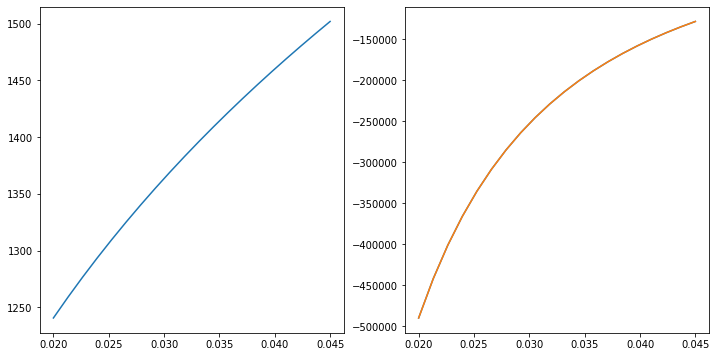

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].plot(masses, TDM_ana)
ax[1].plot(masses, dd_num, label="num")
ax[1].plot(masses, dd_ana, label="ana")

In [12]:
#imp.reload(derivatives)
#from derivatives import derivativeTDM_wrt_M, dderivativeT_wrt_M
#from utils import T_DM

from _utils import derivativeTDM_wrt_M, dderivativeT_wrt_M

def derivativeT_wrt_M(M, r, A, A_cte, alpha, v, c):
    xi   = np.transpose(np.asarray([A, M]))
    Tint = griddata(points, values, xi)[0]
    TDM  = PL_T_DM(r, M*M_sun.value, A_cte, alpha, v=v)
    Ttot = np.power(Tint**4+TDM**4, 0.25)
    
    return (Tint/Ttot)**3*c(A) +  (TDM/Ttot)**3*derivativeTDM_wrt_M(r, M, A_cte, alpha, v)

dd_num = []; dd_ana = []

for M in masses:
    xi   = np.transpose(np.asarray([A, M]))
    Tint = griddata(points, values, xi)[0]
    TDM  = PL_T_DM(r, M*M_sun.value, A_cte, alpha, v)
    Ttot = np.power(Tint**4+TDM**4, 0.25)
        
    dd_num.append(derivative(derivativeT_wrt_M, M, args=(r, A, A_cte, alpha, v, c_interp), dx=1e-5))    

FIXME: some issues in here

In [13]:
#xi   = np.transpose(np.asarray([A, masses[:]]))
#print(masses.shape, xi.shape, points.shape, values.shape)
#print(xi)
#Tint = griddata(points, values, xi)[0]

Tint = []
for M in masses:
    xi   = np.transpose(np.asarray([A, M]))
    Tint.append(griddata(points, values, xi)[0])

Tint = np.asarray(Tint)

In [14]:
TDM  = PL_T_DM(r, masses*M_sun.value, A_cte, alpha, v)
Ttot = np.power(Tint**4+TDM**4, 0.25)

dd_ana = dderivativeT_wrt_M(r, masses, A, Tint, TDM, Ttot, c_interp, A_cte, alpha, v)

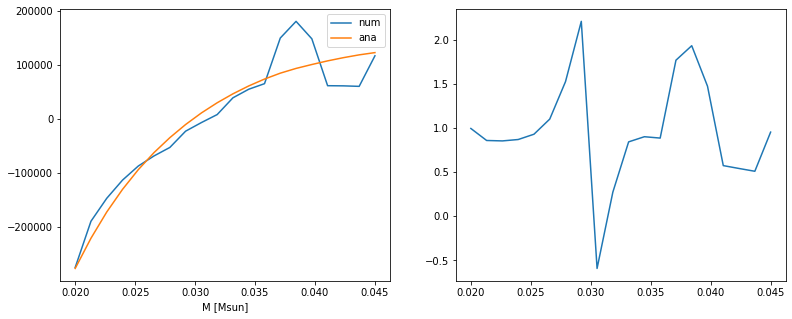

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].plot(masses, dd_num, label="num")
ax[0].plot(masses, dd_ana, label="ana"); ax[0].legend()
ax[0].set_xlabel("M [Msun]")
dd_num = np.asarray(dd_num); dd_ana = np.asarray(dd_ana)
ax[1].plot(masses, dd_num/dd_ana)

# Second derivative temperature with respect to age

In [65]:
import derivatives
import imp
imp.reload(derivatives)
import numpy as np

from derivatives import dderivativeT_wrt_A, dderivativeTint_wrt_A

In [66]:
r=0.1; f=1.; params=[1., 20., 0.42]; v=100.; 
M=0.035; 
ages=np.linspace(1, 10, 30)
M = 0.03

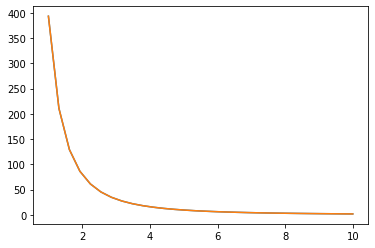

In [19]:
from utils import T_DM

def derivativeTintana_wrt_A(A, M, a, b, Tint, Ttot):                                           
    """                                                                            
    Return (analytical) derivative of interinsic temperature wrt age [K/Gyr]    
    (ATMO temperatures are fitted by a/A^b)                                        
                                                                                   
    Input                                                                          
    -----                                                                          
        M : mass [Msun]                                                            
        A : age [Gyr]                                                              
        a : =f(M) - interpolation function                                         
        b : =f(M) - interpolation function                                         
    """                                                                            
    return (-a(M)*b(M)*np.power(A, -b(M)-1)) 

dd_num = []
dd_ana = []

TDM = T_DM(r, M=M*M_sun.value, f=f, params=params, v=v)

for A in ages:
    xi   = np.transpose(np.asarray([A, M]))
    _Tint = griddata(points, values, xi)[0]
    Ttot  = np.power(_Tint**4 + TDM**4, 0.25)
    
    dd_ana.append(derivative(derivativeTintana_wrt_A, A, args=(M, a_interp, b_interp, _Tint, Ttot), dx=1e-5))    
    dd_num.append(dderivativeTint_wrt_A(M, A, a_interp, b_interp))
    
fig, ax = plt.subplots()
ax.plot(ages, dd_ana)
ax.plot(ages, dd_num)

In [67]:
from utils import T_DM

def derivativeTintana_wrt_A(A, M, a, b, Tint, Ttot):                                           
    """                                                                            
    Return (analytical) derivative of interinsic temperature wrt age [K/Gyr]    
    (ATMO temperatures are fitted by a/A^b)                                        
                                                                                   
    Input                                                                          
    -----                                                                          
        M : mass [Msun]                                                            
        A : age [Gyr]                                                              
        a : =f(M) - interpolation function                                         
        b : =f(M) - interpolation function                                         
    """                                                                            
    return (Tint/Ttot)**3*(-a(M)*b(M)*np.power(A, -b(M)-1)) 

dd_num = []

TDM = T_DM(r, M=M*M_sun.value, f=f, params=params, v=v)

for A in ages:
    xi   = np.transpose(np.asarray([A, M]))
    _Tint = griddata(points, values, xi)[0]
    Ttot  = np.power(_Tint**4 + TDM**4, 0.25)
    
    dd_num.append(derivative(derivativeTintana_wrt_A, A, args=(M, a_interp, b_interp, _Tint, Ttot), dx=1e-5))

In [70]:
Tint = []
for A in ages:
    xi   = np.transpose(np.asarray([A, M]))
    Tint.append(griddata(points, values, xi)[0])

Tint = np.asarray(Tint)
Ttot = np.power(Tint**4 + TDM**4, 0.25)

dd_ana = dderivativeT_wrt_A(M, ages, Tint, Ttot, a_interp, b_interp)

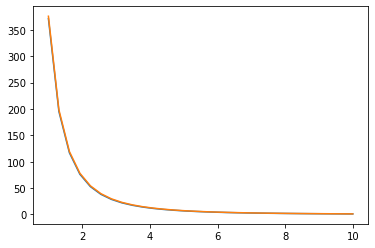

In [71]:
fig, ax = plt.subplots()
ax.plot(ages, dd_ana)
ax.plot(ages, dd_num)

# Second derivative temperature with respect to Galactocentric distance

In [16]:
from _utils import dderivativeT_wrt_r, dderivativeTDM_wrt_r, derivativeTDM_wrt_r

In [17]:
radius=np.linspace(0.1, 1, 20); A_ctes=150.; alpha=1.; v=100.; 
M=0.023; A=5.4

xi   = np.transpose(np.asarray([A, M]))
Tint = griddata(points, values, xi)[0]

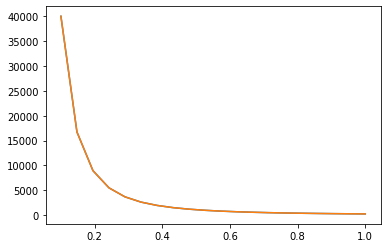

In [19]:
dd_ana = []
dd_num = []

for r in radius:
    TDM  = PL_T_DM(r, M*M_sun.value, A_cte, alpha, v)
    Ttot = np.power(Tint**4 + TDM**4, 0.25)
    
    dd_num.append(derivative(derivativeTDM_wrt_r, r, args=(M, A_cte, alpha, v), dx=1e-5))
    
    dervTDM_r = derivativeTDM_wrt_r(r, M, A_cte, alpha, v)    
    dd_ana.append(dderivativeTDM_wrt_r(r, A_cte, alpha, M, v, TDM, dervTDM_r))
    
fig, ax = plt.subplots()
ax.plot(radius, dd_ana)
ax.plot(radius, dd_num)

In [23]:
imp.reload(_utils)
from _utils import dderivativeT_wrt_r

#dd_ana = []
dd_num = []

from astropy.constants import sigma_sb, G
#from utils import gNFW_rho
_sigma_sb = sigma_sb.value                                                      
_G        = G.value                                                             
conversion_into_K_vs_kg = 1.60217e-7                                            
conversion_into_w       = 0.16021766                                            
conv_Msun_to_kg         = 1.98841e+30

def derivativeT_wrt_r(r, M, A, alpha, v, TDM, Ttot, R=R_jup.value, Rsun=8.178,              
                        epsilon=1):                                                
    """                                                                            
    Return (analytical) derivative of DM temperature wrt r @                       
    (f, gamma, rs, rho0, r, M, R) [K/kpc]                                          
                                                                                   
    Assumption: DM velocity and velocity dispersion constant!                      
                                                                                   
    Input                                                                          
    -----                                                                          
        r      : Galactocentric distance [kpc]                                     
        params : DM parameters [f, gamma, rs]                                      
        M      : exoplanet mass [Msun]                                             
    """                                                                            
    # escape velocity                                                              
    vesc   = np.sqrt(2*_G*M*conv_Msun_to_kg/R)*1e-3 # km/s                         
    _vD = v                                                                        
    _vDM   =  np.sqrt(8./(3*np.pi))*_vD # km/s                                     
                                                                                   
    _rhoDM = A*np.power(r, -alpha)  # GeV/cm3!!!!                                  
                                                                                   
    # DM temperature [K]                                                           
    T_DM = np.power((_rhoDM*_vDM*(1+3./2.*np.power(vesc/_vD, 2))*                  
                     conversion_into_w)/(4*_sigma_sb*epsilon), 1./4.)              
                                                                                   
    return(TDM/Ttot)**3*(0.25*T_DM*(-alpha/r)) 
 

for r in radius:
    TDM  = PL_T_DM(r, M*M_sun.value, A_cte, alpha, v)
    Ttot = np.power(Tint**4 + TDM**4, 0.25)
    
    dd_num.append(derivative(derivativeT_wrt_r, r, args=(M, A_cte, alpha, v, TDM, Ttot), dx=1e-5))
    #dd_ana.append(dderivativeT_wrt_r(r, f, params, M, v, TDM, Ttot))

TDM  = PL_T_DM(radius, M*M_sun.value, A_cte, alpha, v)
Ttot = np.power(Tint**4 + TDM**4, 0.25)
dd_ana = dderivativeT_wrt_r(radius, A_cte, alpha, M, v, TDM, Ttot)

Text(0.5, 0, 'radius [kpc]')

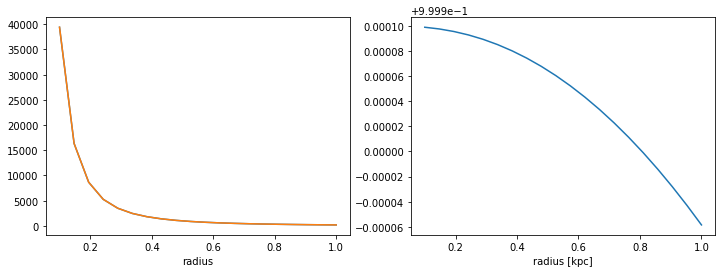

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(radius, dd_ana)
ax[0].plot(radius, dd_num); ax[0].set_xlabel("radius")
ax[1].plot(radius, np.array(dd_ana)/np.array(dd_num)); ax[1].set_xlabel("radius [kpc]")

# Second derivative temperature with respect to mass & age


\begin{equation}
\frac{\partial^2 T}{\partial A \partial M}
\end{equation} 

In [25]:
r=0.1; A=179.; alpha=0.8; v=100.; 
M=0.025; ages=np.linspace(1.1, 9.9, 60)

TDM  = PL_T_DM(r, M*M_sun.value, A_cte, alpha, v)

_ages, _c1 = np.genfromtxt(path + "dderv_ana_wrt_MA.dat", unpack=True)
c1_interp  = interp1d(_ages, _c1)

Text(0.5, 0, 'ages [Gyr]')

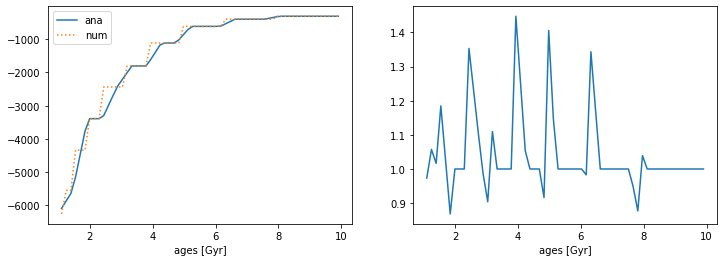

In [9]:
dd_num = []; dd_ana = []

_ages, c = np.genfromtxt(path + "derv_ana_wrt_M.dat", unpack=True)                                                                 

for A in ages:
    xi   = np.transpose(np.asarray([A, M]))
    Tint = griddata(points, values, xi)[0]
    Ttot = np.power(Tint**4 + TDM**4, 0.25)
    
    dd_num.append(derivative(interp1d(_ages, c), A, dx=1e-6))
    dd_ana.append(c1_interp(A))
    
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(ages, dd_ana, label="ana")
ax[0].plot(ages, dd_num, ls=":", label="num"); ax[0].set_xlabel("ages [Gyr]"); ax[0].legend()
dd_ana = np.asarray(dd_ana); dd_num = np.asarray(dd_num)
ax[1].plot(ages, dd_ana/dd_num); 
ax[1].set_xlabel("ages [Gyr]")    

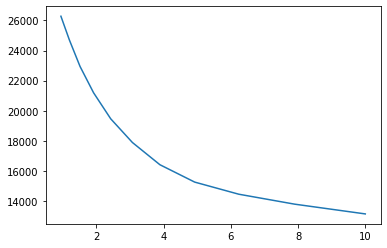

In [68]:
fig, ax = plt.subplots()
ax.plot(_ages, c_interp(_ages))

In [26]:
from _utils import dderivativeT_wrt_MA, derivativeTDM_wrt_M


def dervT_M (A, r, A_cte, alpha, M, v, c, TDM):
    xi   = np.transpose(np.asarray([A, M]))
    Tint = griddata(points, values, xi)[0]
    Ttot = np.power(Tint**4 + TDM**4, 0.25)
    return ((Tint/Ttot)**3* c(A) + (TDM/Ttot)**3*derivativeTDM_wrt_M(r, M, A_cte, alpha, v))

dd_num = []; #dd_ana = []

for A in ages:
    #xi   = np.transpose(np.asarray([A, M]))
    #Tint = griddata(points, values, xi)[0]
    #Ttot = np.power(Tint**4 + TDM**4, 0.25)
    
    dd_num.append(derivative(dervT_M, A, args=(r, A_cte, alpha, M, v, c_interp, TDM), dx=1e-6))
    
    #dd_ana.append(dderivativeT_wrt_MA(r, M, A, a_interp, b_interp, c_interp, 
    #                                  c1_interp, Tint, TDM, Ttot, f, params, v))


In [27]:
Tint = []
for A in ages:
    xi   = np.transpose(np.asarray([A, M]))
    Tint.append(griddata(points, values, xi)[0])
Tint = np.asarray(Tint)
Ttot = np.power(Tint**4 + TDM**4, 0.25)
    
dd_ana = dderivativeT_wrt_MA(r, M, ages, a_interp, b_interp, c_interp, c1_interp, 
                             Tint, TDM, Ttot, A_cte, alpha, v)

Text(0.5, 0, 'ages [Gyr]')

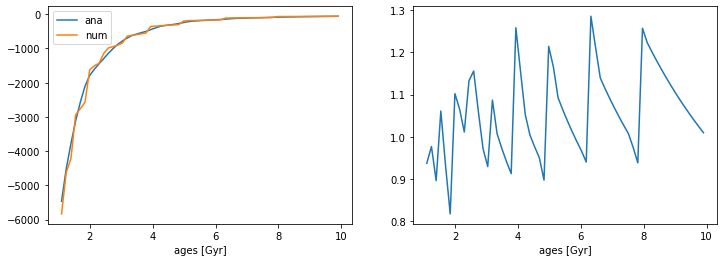

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(ages, dd_ana, label="ana")
ax[0].plot(ages, dd_num, label="num"); ax[0].set_xlabel("ages [Gyr]"); ax[0].legend()
dd_ana = np.asarray(dd_ana); dd_num = np.asarray(dd_num)
ax[1].plot(ages, dd_ana/dd_num); ax[1].set_xlabel("ages [Gyr]")


\begin{equation}
\frac{\partial^2 T}{\partial M \partial A}
\end{equation}

In [29]:
r=0.1; A_cte=321.; alpha=1.9; v=100.; 
masses = np.linspace(0.02, 0.045, 40); A=7.896523

In [41]:
!head /home/mariacst/exoplanets/running/data/dderv_ana_wrt_AM.dat

# Tint = a*masses + b
# da/dM = 25918.3 K/Gyr/Msun
# masses [Msun]  db/dM [K/Msun]
0.015000  5.150859
0.016000  5.150859
0.017000  4.826369
0.018000  3.777572
0.019000  3.317085
0.020000  3.394401
0.021000  3.618423


In [22]:
from _utils import derivativeTintana_wrt_A, dderivativeTint_wrt_AM

dd_num = []
dd_ana = []

_masses, _b1 = np.genfromtxt(path + "dderv_ana_wrt_AM.dat", unpack=True)
b1_interp  = interp1d(_masses, _b1)

for M in masses:
    
    dd_num.append(derivative(derivativeTintana_wrt_A, M, args=(A, a_interp, b_interp), dx=1e-5))
    dd_ana.append(dderivativeTint_wrt_AM(M, A, a_interp, b_interp, b1_interp))

Text(0.5, 0, 'masses [Msun]')

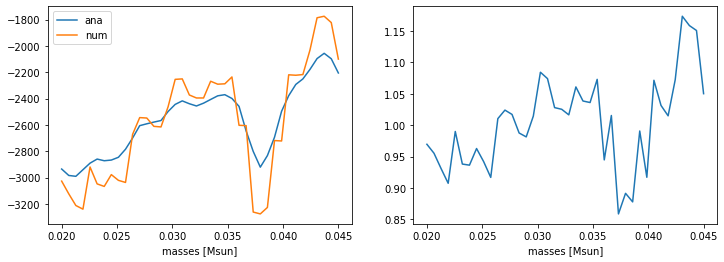

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(masses, dd_ana, label="ana")
ax[0].plot(masses, dd_num, label="num"); ax[0].set_xlabel("masses [Msun]"); ax[0].legend()
dd_ana = np.asarray(dd_ana); dd_num = np.asarray(dd_num)
ax[1].plot(masses, dd_ana/dd_num); ax[1].set_xlabel("masses [Msun]")

In [30]:
from _utils import derivativeTintana_wrt_A, dderivativeT_wrt_AM

dd_num = []; #dd_ana = []

_masses, _b1 = np.genfromtxt(path + "dderv_ana_wrt_AM.dat", unpack=True)
b1_interp  = interp1d(_masses, _b1)


def dervT_wrt_A(M, A, a, b):
    xi   = np.transpose(np.asarray([A, M]))
    Tint = griddata(points, values, xi)[0]
    TDM  = PL_T_DM(r, M*M_sun.value, A_cte, alpha, v)
    Ttot = np.power(Tint**4 + TDM**4, 0.25)
    return (Tint/Ttot)**3*derivativeTintana_wrt_A(M, A, a, b)

for M in masses:  
    #xi   = np.transpose(np.asarray([A, M]))
    #Tint = griddata(points, values, xi)[0]
    #TDM  = T_DM(r, M=M*M_sun.value, f=f, params=params, v=v)
    #Ttot = np.power(Tint**4 + TDM**4, 0.25)    
    
    dd_num.append(derivative(dervT_wrt_A, M, args=(A, a_interp, b_interp), dx=1e-5))
    
    #dd_ana.append(dderivativeT_wrt_AM(r, M, A, a_interp, b_interp, b1_interp, c_interp, 
    #                                  Tint, TDM, Ttot, f, params, v))

In [31]:
Tint = []
for M in masses:
    xi   = np.transpose(np.asarray([A, M]))
    Tint.append(griddata(points, values, xi)[0])
Tint = np.asarray(Tint)
TDM  = PL_T_DM(r, masses*M_sun.value, A_cte, alpha, v)
Ttot = np.power(Tint**4 + TDM**4, 0.25)

dd_ana = dderivativeT_wrt_AM(r, masses, A, a_interp, b_interp, b1_interp, c_interp, Tint, TDM, 
                             Ttot, A_cte, alpha, v)

Text(0.5, 0, 'masses [Msun]')

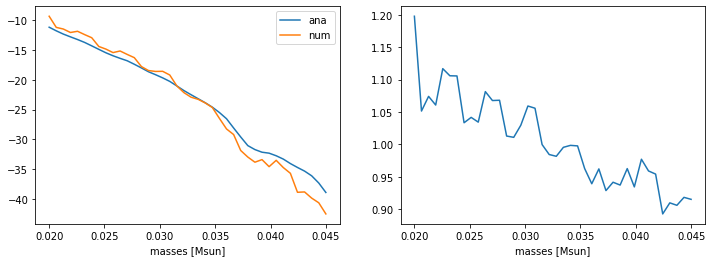

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(masses, dd_ana, label="ana")
ax[0].plot(masses, dd_num, label="num"); ax[0].set_xlabel("masses [Msun]"); ax[0].legend()
dd_ana = np.asarray(dd_ana); dd_num = np.asarray(dd_num)
ax[1].plot(masses, dd_ana/dd_num); ax[1].set_xlabel("masses [Msun]")

# Second derivative temperature with respect to radius & age

\begin{equation}
\frac{\partial^2 T}{\partial r \partial A} = 
\frac{\partial^2 T}{\partial A \partial r}
\end{equation}

I have checked also the equality!

In [33]:
r=0.1; A_cte=49.; alpha=0.3; v=100.; 
M=0.035; ages=np.linspace(1.1, 9.9, 20)

TDM  = PL_T_DM(r, M*M_sun.value, A_cte, alpha, v)

In [35]:
from _utils import derivativeTDM_wrt_r, derivativeTintana_wrt_A

def dderivativeT_wrt_rA(A, M, r, a, b, Tint, TDM, Ttot, A_cte, alpha, v):             
    """                                                                            
    delta_{A, r}^2(temperature) = delta_{r, A}^2(temperature)                      
    """                                                                            
    # return                                                                       
    return (-3./Ttot*(TDM/Ttot)**3*derivativeTDM_wrt_r(r, M, A_cte, alpha, v)*        
        (Tint/Ttot)**3*derivativeTintana_wrt_A(M, A, a, b))   

def dervT_wrt_rA(A, r, A_cte, alpha, M, v, TDM):
    xi   = np.transpose(np.asarray([A, M]))
    Tint = griddata(points, values, xi)[0]
    Ttot = np.power(Tint**4+TDM**4, 0.25)
    return (TDM/Ttot)**3*derivativeTDM_wrt_r(r, M, A_cte, alpha, v)

def dervT_wrt_Ar(r, A, A_cte, alpha, M, v, Tint, a, b):
    TDM  = PL_T_DM(r, M*M_sun.value, A_cte, alpha, v)
    Ttot = np.power(Tint**4+TDM**4, 0.25)
    return (Tint/Ttot)**3*derivativeTintana_wrt_A(M, A, a, b)

In [36]:
dd_num_rA = []; dd_ana = []; dd_num_Ar = []

for A in ages:
    xi   = np.transpose(np.asarray([A, M]))
    Tint = griddata(points, values, xi)[0]
    
    dd_num_rA.append(derivative(dervT_wrt_rA, A, args=(r, A_cte, alpha, M, v, TDM), dx=1e-5))
    
    dd_num_Ar.append(derivative(dervT_wrt_Ar, r, args=(A, A_cte, alpha, M, v, Tint, a_interp, b_interp), dx=1e-6))
    
    #Ttot = np.power(Tint**4+TDM**4, 0.25)
    #dd_ana.append(dderivativeT_wrt_rA(A, M, r, a_interp, b_interp, Tint, TDM, Ttot, f, params, v))

In [37]:
Tint = []
for A in ages:
    xi   = np.transpose(np.asarray([A, M]))
    Tint.append(griddata(points, values, xi)[0])
Tint = np.asarray(Tint); Ttot = np.power(Tint**4+TDM**4, 0.25)

dd_ana = dderivativeT_wrt_rA(ages, M, r, a_interp, b_interp, Tint, TDM, Ttot, A_cte, alpha, v)

Text(0.5, 0, 'ages [Gyr]')

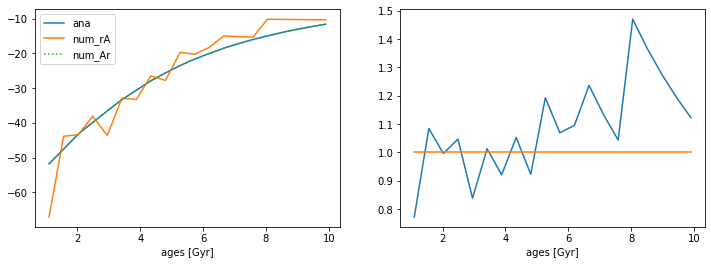

In [38]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(ages, dd_ana, label="ana")
ax[0].plot(ages, dd_num_rA, label="num_rA"); ax[0].set_xlabel("ages [Gyr]")
ax[0].plot(ages, dd_num_Ar, ls=":", label="num_Ar"); ax[0].legend()
dd_ana = np.asarray(dd_ana); dd_num = np.asarray(dd_num)
ax[1].plot(ages, dd_ana/dd_num_rA); ax[1].plot(ages, dd_ana/dd_num_Ar);
ax[1].set_xlabel("ages [Gyr]")

# Second derivative temperature with respect to radius & mass

\begin{equation}
\frac{\partial^2 T_{DM}}{\partial r \partial M}
\end{equation} 

Primero , chequeo la derivada de la densidad con respecto al radio

In [39]:
def gNFW_rho(R, Rsun, parameters):                                                 
    """                                                                            
    Return gNFW density profile at r distance from the GC                          
    Denstiy has same units as local DM density rho0                                
    """                                                                            
    # gNFW parameters                                                              
    gamma = parameters[0]                                                          
    Rs    = parameters[1]                                                          
    rho0  = parameters[2]                                                          
    # Density profile                                                              
    rho   = rho0*np.power(Rsun/R, gamma)*np.power((Rs+Rsun)/(Rs+R), 3-gamma)    
    # Return                                                                       
    return rho 

def derv_rho(R, Rsun, params):
    rhoDM = gNFW_rho(R, Rsun, params)
    return -rhoDM*(params[0]/R + (3.-params[0])/(params[1]+R))

In [34]:
radius = np.linspace(0.1, 1., 20); params = [1., 20., 0.42]

dd_num = []; dd_ana = derv_rho(radius, 8.178, params)

for r in radius:
    dd_num.append(derivative(gNFW_rho, r, args=(8.178, params), dx=1e-7))

Text(0.5, 0, 'radius [kpc]')

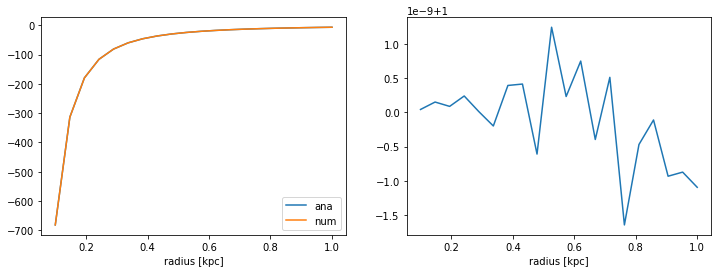

In [35]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(radius, dd_ana, label="ana")
ax[0].plot(radius, dd_num, label="num"); ax[0].set_xlabel("radius [kpc]"); ax[0].legend()
dd_ana = np.asarray(dd_ana); dd_num = np.asarray(dd_num)
ax[1].plot(radius, dd_ana/dd_num); ax[1].set_xlabel("radius [kpc]") 

In [111]:
imp.reload(derivatives)
from derivatives import dderivativeTDM_wrt_Mr

print(derv_rho(radius[3], 8.178, params))
test = dderivativeTDM_wrt_Mr(radius[3], 1., params, 0.03, 100., 100.)

-680.5801636426154


Y ahora la doble derivada de TDM

In [41]:
#imp.reload(derivatives)
from _utils import dderivativeTDM_wrt_rM, derivativeTDM_wrt_M, derivativeTDM_wrt_r

In [42]:
radius=np.linspace(0.1, 1., 20); A_cte=150.; alpha=0.5; v=100.; 
M=0.035; A=4.5

-9391.527067889114


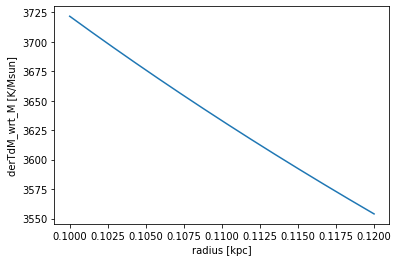

In [106]:
radius = np.linspace(0.1, 0.12, 700)
dervTDM_M = derivativeTDM_wrt_M(radius, f, params, M, v)
    
fig, ax = plt.subplots()
ax.plot(radius, dervTDM_M); ax.set_xlabel("radius [kpc]");
ax.set_ylabel("derTdM_wrt_M [K/Msun]")

print((dervTDM_M[2]-dervTDM_M[1])/(radius[2]-radius[1]))

In [5]:
dd_num = []
for r in radius:  
    dd_num.append(derivative(derivativeTDM_wrt_M, r, args=(M, A_cte, alpha, v), dx=1e-7))   

In [44]:
TDM = PL_T_DM(radius, M*M_sun.value, A_cte, alpha, v=v)
dd_ana = dderivativeTDM_wrt_rM(radius, M, A, c_interp, A_cte, alpha, M, v, TDM)

TypeError: dderivativeTDM_wrt_rM() takes 5 positional arguments but 6 were given

In [8]:
print(dd_num[0], dd_ana[0])

-9396.536113399634 -9396.535682921547


Text(0.5, 0, 'radius [kpc]')

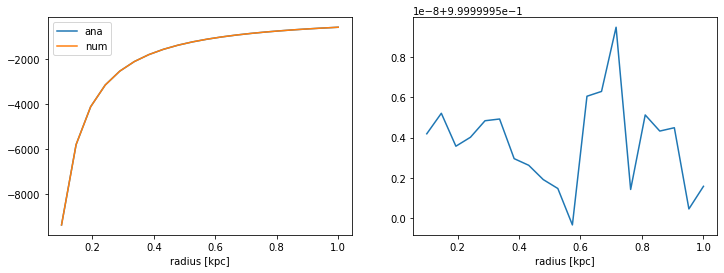

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(radius, dd_ana, label="ana")
ax[0].plot(radius, dd_num, label="num"); ax[0].set_xlabel("radius [kpc]"); ax[0].legend()
dd_ana = np.asarray(dd_ana); dd_num = np.asarray(dd_num)
ax[1].plot(radius, dd_ana/dd_num); ax[1].set_xlabel("radius [kpc]")

\begin{equation}
\frac{\partial^2 T}{\partial r \partial M}
\end{equation}

In [45]:
dd_num = []; #dd_ana = []

xi   = np.transpose(np.asarray([A, M]))
Tint = griddata(points, values, xi)[0]

def dervT_M (r, A, A_cte, alpha, M, v, c, Tint): 
    TDM  = PL_T_DM(r, M*M_sun.value, A_cte, alpha, v)
    Ttot = np.power(Tint**4 + TDM**4, 0.25)
    return ((Tint/Ttot)**3* c(A) + (TDM/Ttot)**3*derivativeTDM_wrt_M(r, M, A_cte, alpha, v))
    

for r in radius:  
    dd_num.append(derivative(dervT_M, r, args=(A, A_cte, alpha, M, v, c_interp, Tint), dx=1e-5))
    
    #TDM  = T_DM(r, M=M*M_sun.value, f=f, params=params, v=v)
    #Ttot = np.power(Tint**4 + TDM**4, 0.25)
    #dd_ana.append(dderivativeT_wrt_Mr(r, M, A, c_interp, Tint, TDM, Ttot, f, params, v))

In [47]:
from _utils import dderivativeT_wrt_Mr

TDM = PL_T_DM(radius, M*M_sun.value, A_cte, alpha, v)
Ttot = np.power(Tint**4 + TDM**4, 0.25)

dd_ana = dderivativeT_wrt_Mr(radius, M, A, c_interp, Tint, TDM, Ttot, A_cte, alpha, v)

ImportError: cannot import name 'dderivativeT_wrt_Mr'

Text(0.5, 0, 'radius [kpc]')

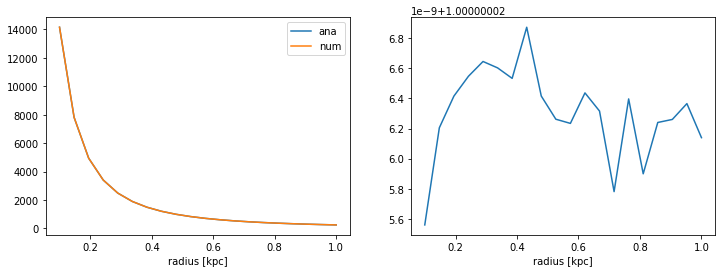

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(radius, dd_ana, label="ana")
ax[0].plot(radius, dd_num, label="num"); ax[0].set_xlabel("radius [kpc]"); ax[0].legend()
dd_ana = np.asarray(dd_ana); dd_num = np.asarray(dd_num)
ax[1].plot(radius, dd_ana/dd_num); ax[1].set_xlabel("radius [kpc]")

\begin{equation}
\frac{\partial^2 T_{DM}}{\partial M \partial r}
\end{equation} 

In [49]:
_sigma_sb = sigma_sb.value                                                      
_G        = G.value                                                             
conversion_into_K_vs_kg = 1.60217e-7                                            
conversion_into_w       = 0.16021766                                            
conv_Msun_to_kg         = 1.98841e+30

#from utils import gNFW_rho

def derivativeTDM_wrt_r(M, r, A, alpha, v, R=R_jup.value, Rsun=8.178,              
                        epsilon=1):                                                
    """                                                                            
    Return (analytical) derivative of DM temperature wrt r @                       
    (f, gamma, rs, rho0, r, M, R) [K/kpc]                                          
                                                                                   
    Assumption: DM velocity and velocity dispersion constant!                      
                                                                                   
    Input                                                                          
    -----                                                                          
        r      : Galactocentric distance [kpc]                                     
        params : DM parameters [f, gamma, rs]                                      
        M      : exoplanet mass [Msun]                                             
    """                                                                            
    # escape velocity                                                              
    vesc   = np.sqrt(2*_G*M*conv_Msun_to_kg/R)*1e-3 # km/s                         
    _vD = v                                                                        
    _vDM   =  np.sqrt(8./(3*np.pi))*_vD # km/s                                     
                                                                                   
    _rhoDM = A*np.power(r, -alpha)  # GeV/cm3!!!!                                  
                                                                                   
    # DM temperature [K]                                                           
    T_DM = np.power((_rhoDM*_vDM*(1+3./2.*np.power(vesc/_vD, 2))*                  
                     conversion_into_w)/(4*_sigma_sb*epsilon), 1./4.)              
                                                                                   
    return(0.25*T_DM*(-alpha/r)) 

In [50]:
masses = np.linspace(0.02, 0.045, 40)
r=0.2; A_cte=165.; alpha=0.7; v=100.; A=4.5

In [51]:
dd_num = []
for M in masses:
    dd_num.append(derivative(derivativeTDM_wrt_r, M, args=(r, A_cte, alpha, v), dx=1e-5))

In [54]:
from _utils import dderivativeTDM_wrt_rM

dd_ana = dderivativeTDM_wrt_rM(r, masses, A_cte, alpha, v)

Text(0.5, 0, 'masses [Msun]')

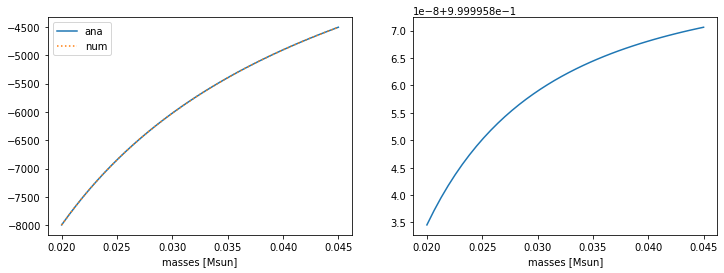

In [55]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(masses, dd_ana, label="ana")
ax[0].plot(masses, dd_num, label="num", ls=":"); ax[0].set_xlabel("masses [Msun]"); ax[0].legend()
dd_ana = np.asarray(dd_ana); dd_num = np.asarray(dd_num)
ax[1].plot(masses, dd_ana/dd_num); ax[1].set_xlabel("masses [Msun]")

In [57]:
from _utils import derivativeTDM_wrt_r

masses = np.linspace(0.02, 0.045, 40)
r=0.2; A_cte=76; alpha=0.8; v=100.; A=4.5

def dervT_wrt_r(M, r, A_cte, alpha, v, A):
    xi   = np.transpose(np.asarray([A, M]))
    Tint = griddata(points, values, xi)[0]
    
    TDM  = PL_T_DM(r, M*M_sun.value, A_cte, alpha, v)
    
    Ttot = np.power(Tint**4 + TDM**4, 0.25) 
    
    return (TDM/Ttot)**3*derivativeTDM_wrt_r(r, M, A_cte, alpha, v)

240.23505658878827


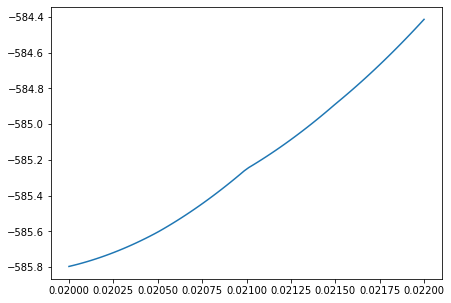

In [58]:
_masses = np.linspace(0.02, 0.022, 80)
dervT_r = []
for M in _masses:
    dervT_r.append(dervT_wrt_r(M, r, A_cte, alpha, v, A))
dervT_r = np.asarray(dervT_r)
    
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.plot(_masses, dervT_r)

print((dervT_r[1]-dervT_r[0])/(_masses[1]-_masses[0]))

In [59]:
Tint   = []
dd_num = []

masses = np.linspace(0.02, 0.045, 80)

for M in masses:
    dd_num.append(derivative(dervT_wrt_r, M, args=(r, A_cte, alpha, v, A), dx=1e-5))
    
    xi   = np.transpose(np.asarray([A, M]))
    Tint.append(griddata(points, values, xi)[0])
    
Tint = np.asarray(Tint)

In [60]:
#imp.reload(derivatives)
from _utils import dderivativeT_wrt_rM
    

TDM  = PL_T_DM(r, masses*M_sun.value, A_cte, alpha, v)    
Ttot = np.power(Tint**4 + TDM**4, 0.25)    

dd_ana = dderivativeT_wrt_rM(r, masses, A, c_interp, Tint, TDM, Ttot, A_cte, alpha, v)

print(dd_num[0], dd_ana[0])

166.10457353749553 404.1564052581871


Text(0.5, 0, 'masses [Msun]')

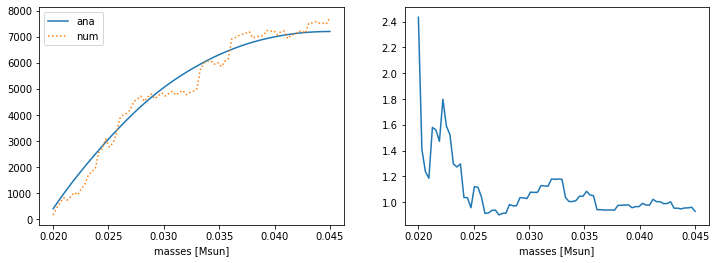

In [61]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(masses, dd_ana, label="ana")
ax[0].plot(masses, dd_num, label="num", ls=":"); ax[0].set_xlabel("masses [Msun]"); ax[0].legend()
dd_ana = np.asarray(dd_ana); dd_num = np.asarray(dd_num)
ax[1].plot(masses, dd_ana/dd_num); ax[1].set_xlabel("masses [Msun]")

# Check the corrections

In [1]:
import sys
sys.path.append("/home/mariacst/exoplanets/exoplanets/cluster/")
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from _utils import sigma_Tmodel2, delta_sigma_Tmodel2
#import imp
#import _utils
#imp.reload(_utils)
from _utils import T_DM, delta_temperature_withDM

In [3]:
# Load theoretical cooling model                                                   
path = "/home/mariacst/exoplanets/running/data/"                                   
data = np.genfromtxt(path + "./ATMO_CEQ_vega_MIRI.txt", unpack=True)               
points = np.transpose(data[0:2, :])                                                
values = data[2]                                                                   
# Mock observation   
rank=42; nBDs=100; relTobs=0.1; sigma=0.1; f_true=1.; gamma_true=1.; rs_true=20.; rho0=0.42; Tcut=650.; v=100;


from mock_generation import mock_population_all

np.random.seed(rank)                                                               
(robs, sigmarobs, Tobs, sigmaTobs, Mobs,                                           
     sigmaMobs, Aobs, sigmaAobs) = mock_population_all(nBDs, relTobs, sigma,    
                                      sigma, sigma, f_true, gamma_true,            
                                      rs_true, rho0_true=rho0, Tmin=Tcut, v=v)

In [4]:
from scipy.interpolate import griddata, interp1d
## calculate predictic intrinsic temperature                                       
xi       = np.transpose(np.asarray([Aobs, Mobs]))                                  
Teff     = griddata(points, values, xi)

In [5]:
# Load variables analytical derivatives Tint                                       
masses, a, b = np.genfromtxt(path + "derv_ana_wrt_A.dat", unpack=True)             
ages, c = np.genfromtxt(path + "derv_ana_wrt_M.dat", unpack=True)                  
a_interp = interp1d(masses, a)                                                     
b_interp = interp1d(masses, b)                                                     
c_interp = interp1d(ages, c)                                                       
masses, b1 = np.genfromtxt(path + "dderv_ana_wrt_AM.dat", unpack=True)             
b1_interp  = interp1d(masses, b1)

In [6]:
conv_Msun_to_kg = 1.98841e+3

In [7]:
TDM = T_DM(robs, M=Mobs*conv_Msun_to_kg, f=f_true, params=[gamma_true, rs_true, rho0], v=v)

(array([0.00974989, 0.01772707, 0.00886354, 0.0115226 , 0.00974989,
        0.00797718, 0.00531812, 0.00709083, 0.00709083, 0.00354541]),
 array([142.88699002, 154.16917011, 165.45135019, 176.73353027,
        188.01571036, 199.29789044, 210.58007053, 221.86225061,
        233.14443069, 244.42661078, 255.70879086]),
 [<matplotlib.patches.Polygon at 0x7ff5591b99e8>])

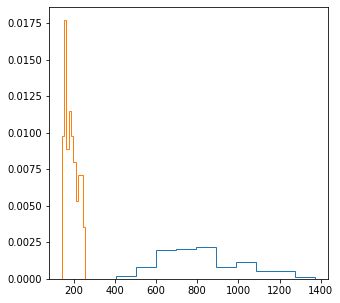

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.hist(Teff, density=True, histtype="step"); ax.hist(TDM, density=True, histtype="step")

In [10]:
Ttot = np.power(np.power(Teff, 4) + np.power(TDM, 4), 0.25)
Tmodel = Ttot + delta_temperature_withDM(robs, Mobs, Aobs, sigmarobs, sigmaMobs, sigmaAobs, Teff, TDM,                     
                                  f_true, [gamma_true, rs_true, rho0], a_interp, b_interp, c_interp, v) 

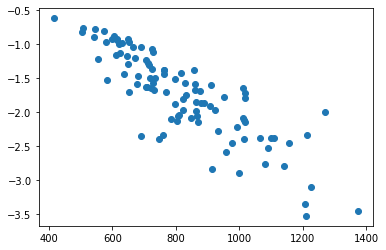

In [15]:
fig, ax = plt.subplots()
#ax.hist(Ttot, histtype="step"); ax.hist(Tmodel, histtype="step")
#ax.plot(Ttot, Ttot, color="k")
ax.scatter(Ttot, Ttot-Tmodel)

In [19]:
sigmaT = sigma_Tmodel2(robs, Mobs, Aobs, sigmarobs, sigmaMobs, sigmaAobs, Teff, TDM, Ttot,                     
                                f_true, [gamma_true, rs_true, rho0], a_interp, b_interp, c_interp, v)

ages, c1  = np.genfromtxt(path + "dderv_ana_wrt_MA.dat", unpack=True)            
c1_interp = interp1d(ages, c1) 
import _utils
import imp
imp.reload(_utils)
from _utils import delta_sigma_Tmodel2

sigmaT_corr = sigmaT + delta_sigma_Tmodel2(robs, Mobs, Aobs, sigmarobs, sigmaMobs, sigmaAobs, Teff, TDM, Ttot,                     
                                f_true, [gamma_true, rs_true, rho0], a_interp, b_interp, b1_interp, c_interp, 
                                c1_interp, v)

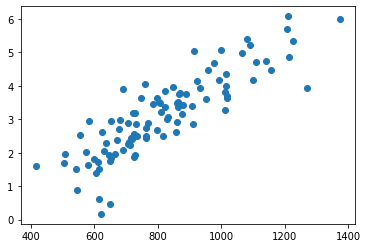

In [25]:
fig, ax = plt.subplots()
ax.scatter(Ttot, np.sqrt(np.abs(sigmaT-sigmaT_corr)))